# Berlin Rent Prices — Summary Statistics Exercise

**Data source:** Wohnatlas Berlin — Angebotsmieten 2022 (net cold rent, €/m²/month)  
**Publisher:** Senatsverwaltung für Stadtentwicklung, Bauen und Wohnen Berlin  
**License:** Datenlizenz Deutschland – Zero – Version 2.0

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## 1. Download the data

In [2]:
WFS_URL = (
    "https://gdi.berlin.de/services/wfs/wa_01_angebotsmieten"
    "?SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature"
    "&TYPENAMES=wa_01_angebotsmieten:wa_01_2022"
    "&OUTPUTFORMAT=application/json"
)

response = requests.get(WFS_URL, timeout=30)
response.raise_for_status()
geojson = response.json()

records = [
    {
        "district": f["properties"]["bezirk"],
        "area": f["properties"]["prognoseraum_bezeichnung"],
        "area_id": f["properties"]["prognoseraum_nummer"],
        "rent_eur_m2": f["properties"]["angebotsmieten"],
    }
    for f in geojson["features"]
    if f["properties"]["angebotsmieten"] is not None
]

df = pd.DataFrame(records)
print(f"Loaded {len(df)} forecast areas across {df['district'].nunique()} districts")
df.head(10)

Loaded 58 forecast areas across 12 districts


,district,area,area_id,rent_eur_m2
0,Mitte,Zentrum,0110,19.52
1,Mitte,Moabit,0120,15.98
2,Mitte,Gesundbrunnen,0130,10.70
3,Mitte,Wedding,0140,11.42
4,Friedrichshain/Kreuzberg,Kreuzberg Nord,0210,9.64
5,Friedrichshain/Kreuzberg,Kreuzberg Süd,0220,15.82
6,Friedrichshain/Kreuzberg,Kreuzberg Ost,0230,13.63
7,Friedrichshain/Kreuzberg,Friedrichshain West,0240,14.61
8,Friedrichshain/Kreuzberg,Friedrichshain Ost,0250,15.81
9,Pankow,Buch,0310,7.85


## 2. Summary statistics

In [3]:
from scipy import stats as sp_stats

rent = df["rent_eur_m2"]

q1  = rent.quantile(0.25)
q3  = rent.quantile(0.75)
iqr = q3 - q1

stats_df = pd.DataFrame({
    "Value": [
        round(rent.mean(), 2),
        round(rent.median(), 2),
        round(rent.std(), 2),
        round(rent.min(), 2),
        round(q1, 2),
        round(q3, 2),
        round(rent.max(), 2),
        round(iqr, 2),
        round(sp_stats.skew(rent), 2),
    ]
}, index=[
    "Mean (euros/m2)",
    "Median (euros/m2)",
    "SD (euros/m2)",
    "Min (euros/m2)",
    "Q1 (euros/m2)",
    "Q3 (euros/m2)",
    "Max (euros/m2)",
    "IQR (euros/m2)",
    "Skewness",
])

display(stats_df)

,Value
Mean (euros/m2),11.37
Median (euros/m2),11.43
SD (euros/m2),2.85
Min (euros/m2),6.26
Q1 (euros/m2),9.25
Q3 (euros/m2),13.20
Max (euros/m2),19.52
IQR (euros/m2),3.96
Skewness,0.44


## 3. Histogram

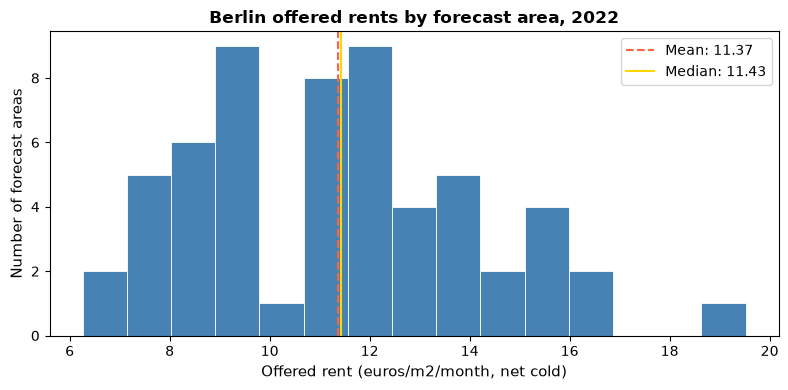

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df["rent_eur_m2"], bins=15, color="steelblue", edgecolor="white", linewidth=0.6)

mean_val   = df["rent_eur_m2"].mean()
median_val = df["rent_eur_m2"].median()

ax.axvline(mean_val,   color="tomato", linewidth=1.5, linestyle="--", label=f"Mean: {mean_val:.2f}")
ax.axvline(median_val, color="gold",   linewidth=1.5, linestyle="-",  label=f"Median: {median_val:.2f}")

ax.set_xlabel("Offered rent (euros/m2/month, net cold)", fontsize=11)
ax.set_ylabel("Number of forecast areas", fontsize=11)
ax.set_title("Berlin offered rents by forecast area, 2022", fontsize=12, fontweight="bold")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))

plt.tight_layout()
plt.savefig("berlin_rent_histogram.png", dpi=150)
plt.show()

## 4. What a headline might say — and what it hides

### The claim

> **"Berlin's average rent stands at just 11.37 euros/m2 — evidence that the city remains one of the most affordable major capitals in Europe."**
> *(hypothetical government press release, 2022)*

### What the summary statistic obscures

The **mean** (11.37) is a geographic average of area-level medians across 58 forecast zones — not a distribution of what individual renters actually pay.

Things it hides:

- **Extreme spread (6.26 to 19.52).** Mitte Zentrum costs three times Märkisches Viertel. One number erases that gap entirely.
- **Right-skewed distribution.** A handful of high-rent central areas pull the mean up; the histogram makes this visible, the headline does not.
- **Apartment size is invisible.** 11 euros/m2 sounds low — but a 70 m2 flat is still 770 euros/month before utilities, above median net income for many Berlin households.
- **Offered vs. existing rents.** These are *Angebotsmieten* — prices on the open market. Long-term tenants pay far less. The figure captures what a new renter faces, not the city average.

**Discussion prompt:** If you were advising a tenant advocacy group, which single number from this dataset would you cite instead, and why?

In [5]:
# Bonus: cheapest and most expensive areas
print("=== 5 cheapest areas ===")
display(df.nsmallest(5, "rent_eur_m2")[["district", "area", "rent_eur_m2"]])

print("\n=== 5 most expensive areas ===")
display(df.nlargest(5, "rent_eur_m2")[["district", "area", "rent_eur_m2"]])

=== 5 cheapest areas ===


,district,area,rent_eur_m2
57,Reinickendorf,Märkisches Viertel,6.26
16,Charlottenburg/Wilmersdorf,Charlottenburg Nord,6.79
37,Neukölln,Gropiusstadt,7.16
48,Lichtenberg/Hohenschönhausen,Hohenschönhausen Nord,7.32
44,Marzahn/Hellersdorf,Marzahn,7.36



=== 5 most expensive areas ===


,district,area,rent_eur_m2
0,Mitte,Zentrum,19.52
20,Charlottenburg/Wilmersdorf,Wilmersdorf Zentrum,16.49
19,Charlottenburg/Wilmersdorf,Wilmersdorf Süd,16.18
1,Mitte,Moabit,15.98
15,Pankow,Südl. Prenzlauer Berg,15.98
